# 2_VQE(+SQD) tutorial

This chapter demonstrates simple VQE and SQD examples, organized around the **Qiskit Pattern**:

1. **Map** the chemistry problem to a qubit Hamiltonian and ansatz  
2. **Optimize** by preparing ISA circuits and aligned observables  
3. **Execute** with Estimator / Sampler in appropriate execution modes  
4. **Post-process** with both **Estimator-based VQE** and **SQD-style projected diagonalization**

and utilizes Qiskit features such as
- Circuit library for ansatz
- Parameterized circuit
- Running local emulators
  - ideal: `StatevectorEstimator` and `StatevectorSampler`
  - noisy: `SamplerV2` and `EstimatorV2` in `qiskit-aer` package
- Accessing real backends with `qiskit_ibm_runtime` package
- Transpilation for target backend
- Execution modes

### Learning goals

By the end of the tutorial, you should be able to:

- build a compact four-qubit H₂ VQE workflow,
- prepare **ISA circuits** and apply the same layout to observables,
- choose between **job / session / batch** execution modes,
- inspect transpilation on both a **real backend target**,
- based on `qiskit-aer` simulation, compare the convergence of:
  - **Estimator-based VQE**, and
  - **SQD-style energy estimation from samples**,
  
  under the **noisy condition**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler import generate_preset_pass_manager


## 2-1. Variational Quantum Eigensolver (VQE) workflow

<center><img src=images/vqe.avif alt="vqe.avif" width="800"/></center>

VQE is a hybrid quantum-classical algorithm for estimating the ground-state energy of a Hamiltonian.  
Instead of diagonalizing the full Hamiltonian exactly, it prepares a parameterized trial state on a quantum circuit and optimizes those parameters so that the measured energy becomes as small as possible.

### Typical VQE workflow

1. **Prepare the problem Hamiltonian**  
   Start from the molecular or spin Hamiltonian written as a sum of Pauli operators,
   $$
   H = \sum_i c_i P_i, \quad P_i \in \{I, X, Y, Z\}^{\otimes n}, ~~c_i\in\mathbb{R}
   $$
   This defines the system whose ground-state energy we want to estimate.

2. **Choose a parameterized ansatz**  
   Construct a quantum circuit $ U(\theta) $ with tunable parameters $\theta$.  
   Acting on an initial state, it prepares a trial state
   $$
   |\psi(\theta)\rangle = U(\theta)|0\rangle.
   $$

3. **Measure the expectation value on a quantum computer**  
   For the current parameters, evaluate
   $$
   E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle.
   $$
   Since $H$ is decomposed into Pauli terms, this is done by measuring the corresponding Pauli observables and combining the results with their coefficients.

4. **Optimize the parameters classically**  
   A classical optimizer updates the parameters $ \theta $ to reduce the measured energy.

5. **Iterate until convergence**  
   The quantum processor and classical optimizer form a loop:
   prepare state $\rightarrow$ measure energy $\rightarrow$ update parameters.  
   When the energy stops improving, the final value approximates the ground-state energy, and the optimized circuit approximates the ground state.

This hybrid structure is what makes VQE attractive for near-term quantum devices: the quantum computer handles state preparation and measurement, while the classical computer handles parameter optimization.


### VQE workflow in the Qiskit pattern

The implementation of VQE can be understood through the **Qiskit pattern**, which organizes quantum applications into four stages: **map**, **optimize**, **execute**, and **post-process**.
In IBM Quantum’s terminology, these correspond to: mapping the problem to quantum circuits and operators, optimizing for target hardware, executing on target hardware, and post-processing results.


**map**: prepares the qubit Hamiltonian and choosing a parameterized ansatz circuit.

**optimize**: transpiles that ansatz into an ISA circuit suitable for the selected backend, including layout selection and basis-gate conversion.

**execute**: estimate the energy expectation value for a given parameter set, typically using the `Estimator` primitive, which returns observable expectation values.  

**post-process**: uses those measured energies in a classical optimization loop to update the variational parameters and check convergence.


![VQE in Qiskit Pattern](images/vqe_qiskit_pattern.png)


--------

## 2-2. Map: Problem Hamiltonian and Ansatz


### Hamiltonian
We use the precalculated **4-qubit H₂ Hamiltonian**.
The molecular Hamiltonian is derived from a classical electronic-structure calculation, called Hartree-Fock method with **STO-3G** atomic orbital basis set.
It is then mapped to Pauli operator with [Jordan-Wigner transformation](https://quantum.cloud.ibm.com/learning/en/courses/quantum-computing-in-practice/mapping#jordan-wigner-transformation).

![mol_mapping.jpg](./images/mol_mapping.jpg)

In [2]:
H2_ham = SparsePauliOp([
    'IIII', 'IIIZ', 'IIZI', 'IZII',
    'ZIII', 'IIZZ', 'YXXY', 'XXYY',
    'YYXX', 'XYYX', 'IZIZ', 'ZIIZ',
    'IZZI', 'ZIZI', 'ZZII'
    ],
    coeffs=[
        -0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
        -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
        -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
        0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j
    ]
)

n_qubits = H2_ham.num_qubits
n_electrons = 2


### Exact Diagonalization

Before introducing VQE, we can still diagonalize the Hamiltonian exactly on a classical computer, which gives us a trusted reference ground-state energy.
This exact result will later serve as a benchmark for checking whether the variational procedure converges correctly.

In [3]:
H2_matrix = H2_ham.to_matrix()
with np.printoptions(precision=3, suppress=True, linewidth=200):
    print("Hamiltonian matrix:\n", H2_matrix.real)
print(f"Hamiltonian matrix shape: {H2_matrix.shape}")

exact_evals, exact_evecs = np.linalg.eigh(H2_matrix)
exact_gnd = float(np.min(exact_evals))
exact_gnd_vec = exact_evecs[:, np.argmin(exact_evals)] # Assume non-degenerated

print(f"Exact ground-state energy: {exact_gnd:.10f}")
print(f"Exact ground-state vector: {Statevector(exact_gnd_vec).draw('latex_source')}".replace(r"\rangle", ">"))
print(f"Number of qubits: {n_qubits}")

Hamiltonian matrix:
 [[ 0.714  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.    -0.539  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.    -0.539  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.    -1.117  0.     0.     0.     0.     0.     0.     0.     0.     0.181  0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.238  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.    -0.532  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.    -0.351  0.     0.    -0.181  0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.    -0.447  0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     

Even though this H₂ Hamiltonian is still small enough (16×16) to be diagonalized exactly on a laptop, the matrix size and the classical computational cost grow very quickly as the molecular system becomes larger.
The Hilbert space dimension and the size of the many-body Hamiltonian increase exponentially with the number of considered orbitals, and therefore with the number of qubits.
As an example, a free benzene molecule in the STO-3G basis involves 72 spin orbitals, so the possible Fock basis states scale as $2^{72}\approx 4.7\times 10^{21}$!

H₂ is the minimal example for learning the workflow, while larger molecules rapidly demand much more classical memory and compute.
For larger system with hydrogen chains, see [advanced-1_PrecalculatedHamiltonians.ipynb](advanced-1_PrecalculatedHamiltonians.ipynb), which shows the classical calculation and qubit Hamiltonians for hydrogen chains of increasing size.


### Ansatz
To search for the ground state variationally, we next choose a parameterized quantum circuit, or ansatz, to represent a family of trial states.
The optimizer will tune the circuit parameters so that the expectation value of the Hamiltonian becomes as small as possible.
In this example, we use the hardware efficient `efficient_su2` ansatz provided by Qiskit.



Other ansatz choice include
- [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2): Layers of SU(2) rotations and CX gates, whose connectivity is simplified to make it hardware-efficient.
- [`excitation_preserving`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.excitation_preserving): Preserves number of `1`s in the computational basis state.
- [`evolved_operator_ansatz`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.evolved_operator_ansatz): Usually for quantum-chemistry-inspired ansatz, such as unitary coupled cluster.
- [`n_local`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.n_local): Construct an $n$-local variational circuit.
- [More ansatz circuits](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library#n-local-circuits)

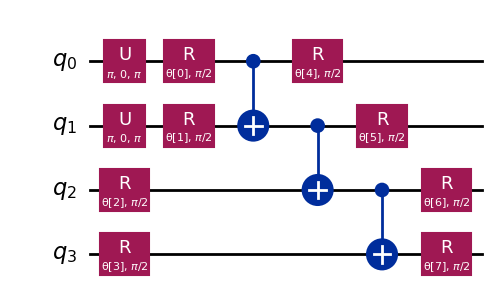

In [4]:
from qiskit.circuit.library import efficient_su2


hf_state = QuantumCircuit(n_qubits)

# Initialize to Hartree-Fock state
for i in range(n_electrons):
    hf_state.x(i)

ansatz = hf_state.compose(
    efficient_su2(
        num_qubits=n_qubits,
        su2_gates=["ry"],
        entanglement="linear",
        reps=1,
        skip_final_rotation_layer=False,
        insert_barriers=False,
    ),
    inplace=False,
)

ansatz.decompose().draw("mpl", idle_wires=False)

In [5]:
num_params = ansatz.num_parameters
x0 = np.zeros(num_params)  # np.ones(num_params) * np.pi/2
parameter_bound = [(-np.pi, np.pi) for _ in range(num_params)]
print("Number of ansatz parameters:", num_params)

Number of ansatz parameters: 8



------------------

## 2-3. Abstract and Ideal Setup - Running on Local Emulator

We first work in purely local mode with `StatevectorEstimator` so that the optimization logic is easy to inspect.

Later we will switch to the **Qiskit Pattern** view:
- abstract circuit / observable (Already done in Section 1),
- transpiled **ISA circuit**,
- layout-applied **ISA observable**,
- execution via `Estimator` or `Sampler`.


In this section, we ignore hardware constraints and use Qiskit’s `StatevectorEstimator`, which evaluates expectation values directly from the exact statevector.  
This gives an ideal, noise-free setting in which the VQE logic is easy to understand: for each parameter vector $\theta$, we prepare the ansatz state, compute the expectation value of the Hamiltonian, and return that value as the objective for the classical optimizer.

The function `estimate_energy_sv(theta)` defines exactly this objective.  
It packages the ansatz, the observable `H2_ham`, and the current parameter values into a **primitive unified block (PUB)**, runs the estimator, and extracts the resulting energy expectation value.  
This is the quantity minimized by [`scipy.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html), which here uses the derivative-free **Powell** method.

We also record the optimization trajectory through the callback function `callback_store(xk)`.  
At each optimizer step, it stores both the current parameter vector and the corresponding estimated energy, which is useful for later visualization of convergence.  
This mirrors the usual VQE workflow: a classical optimizer proposes parameters, the quantum routine evaluates the energy, and the result is fed back into the optimizer.

Once the optimization terminates, `res.x` contains the optimized variational parameters and `res.fun` is the final VQE energy.  
We then compare this value against the exact ground-state energy obtained earlier by direct diagonalization.  
In this ideal statevector setting, the remaining discrepancy comes only from the expressive power of the ansatz and the behavior of the classical optimizer, not from sampling noise or hardware errors.

In [6]:
estimator_sv = StatevectorEstimator()

energy_history = []
param_history = []

def estimate_energy_sv(theta):
    pub = (ansatz, H2_ham, theta)
    result = estimator_sv.run([pub]).result()
    energy = float(np.real(result[0].data.evs))
    param_history.append(np.array(theta, dtype=float))
    energy_history.append(energy)
    return energy

# def callback_store(xk):

res = minimize(
    estimate_energy_sv,
    x0=x0,
    method="cobyla",
    bounds=parameter_bound,
    options={
        "maxiter": 100,
        "disp": True,
    },
)

ideal_vqe_theta = np.array(res.x, dtype=float)
ideal_vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {ideal_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(ideal_vqe_energy-exact_gnd):.3e}")


Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 100   Least value of F = -1.13406417881105   Constraint violation = 0.0
The corresponding X is:
[-0.20676152  0.00833492  0.00951175  0.43044888 -0.00597163  3.14159265
 -0.01472733 -0.42736232]
The constraint value is:
[-2.93483113 -3.14992758 -3.15110441 -3.57204154 -3.13562102 -6.28318531
 -3.12686532 -2.71423033 -3.34835418 -3.13325773 -3.1320809  -2.71114377
 -3.14756429  0.         -3.15631998 -3.56895498]

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Final VQE electronic energy: -1.1340641788
Exact electronic energy:     -1.1372701657
Absolute error:              3.206e-03


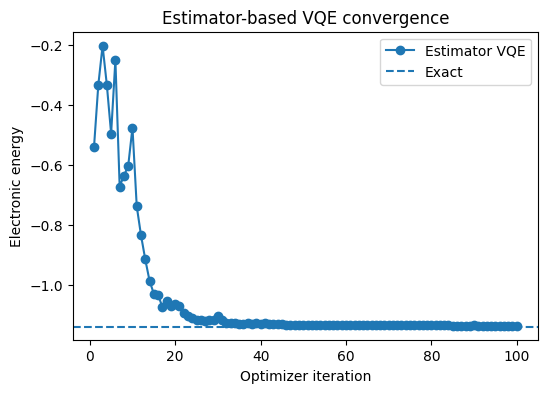

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history)+1), energy_history, marker="o", label="Estimator VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()


--------

## 2-4. Optimization: Mapping to ISA and Transpilation

The ansatz we constructed above is still an abstract circuit, but real hardware can only run circuits that match its supported basis gates and qubit connectivity. Qiskit therefore uses transpilation to convert the ansatz into an **ISA circuit**, which is the hardware-compatible form required for execution on IBM Quantum backends.

In the next cell, we first connect to the IBM Quantum service and select a real device with enough qubits for the demonstration.
Visit [https://quantum.cloud.ibm.com/computers](https://quantum.cloud.ibm.com/computers) for available backends.

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
# This may take a few seconds as it fetches the latest backend information.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
# Or by name:
backend = service.backend("ibm_torino")

print("Selected backend:", backend.name)
print("Backend gate set:", backend.operation_names)
print("Backend coupling map:", backend.coupling_map)
try: # Requires Graphviz to be installed and in PATH
    backend.coupling_map.draw(f"backend_{backend.name}_coupling_map.png")
    print(f"Coupling map diagram saved as backend_{backend.name}_coupling_map.png")
except Exception as e:
    pass

qiskit_runtime_service.__init__:WARNING:2026-03-27 03:50:10,114: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-27 03:50:10,116: Using instance: Solutions Notebooks premium fleet, plan: premium


Selected backend: ibm_torino
Backend gate set: ['cz', 'if_else', 'delay', 'reset', 'id', 'x', 'measure', 'sx', 'rz']
Backend coupling map: [[0, 1], [0, 15], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3], [4, 5], [4, 16], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [8, 7], [8, 9], [8, 17], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [12, 11], [12, 13], [12, 18], [13, 12], [13, 14], [14, 13], [15, 0], [15, 19], [16, 4], [16, 23], [17, 8], [17, 27], [18, 12], [18, 31], [19, 15], [19, 20], [20, 19], [20, 21], [21, 20], [21, 22], [21, 34], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 35], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 36], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 37], [34, 21], [34, 40], [35, 25], [35, 44], [36, 29], [36, 48], [37, 33], [37, 52], [38, 39], [38, 53], [39, 38], [39, 40], [40, 34], [40, 39], [40,

We then generate a preset pass manager with ([`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)), including layout selection, routing, basis-gate translation, and circuit optimization.
This generates a preset [`PassManager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.PassManager), which manages a set of Passes and their schedule during transpilation.

Here we use `optimization_level=3` to request the heaviest built-in optimization level, and `seed_transpiler=1234` to make the stochastic parts of transpilation reproducible.

In [9]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=1234,
)
print("Pass manager stages:", pm.stages)
try: # Requires Graphviz to be installed and in PATH
    pm.draw(f"pass_manager_{backend.name}.png")
    print(f"Pass manager diagram saved as pass_manager_{backend.name}.png")
except Exception as e:
    pass

Pass manager stages: ('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')


After transpilation, the circuit may no longer use the original logical qubit ordering, because the transpiler can choose a new layout to better match the hardware.  
For that reason, the Hamiltonian must also be updated to the same layout.
Qiskit’s `SparsePauliOp.apply_layout(...)` performs exactly this step, ensuring that the observable is aligned with the transpiled ansatz before expectation values are evaluated. 

Finally, we inspect a few basic properties of the resulting ISA circuit, such as its depth, total size, operation counts, and final qubit layout.  
These quantities give a first impression of how costly the ansatz becomes after hardware-aware compilation, and they are often useful when comparing different ansätze or transpilation settings.

ISA Hamiltonian:
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYIIIIIIIIIIIXXYII', 'IIIIIIII

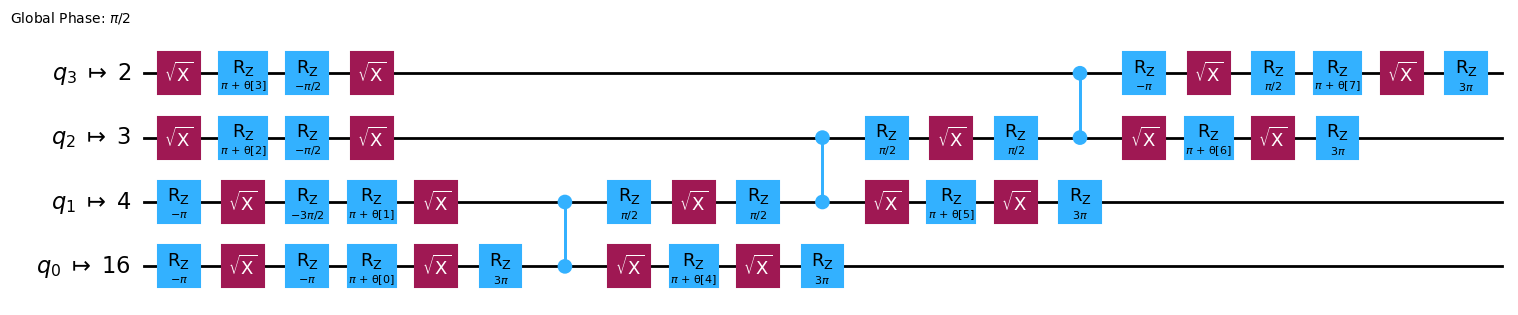

In [10]:
isa_ansatz = pm.run(ansatz)
isa_hamiltonian = H2_ham.apply_layout(isa_ansatz.layout)

print("ISA Hamiltonian:")
print(isa_hamiltonian)

print("ISA depth:", isa_ansatz.depth())
print("ISA size:", isa_ansatz.size())
print("ISA operations:", isa_ansatz.count_ops())
print("Layout:", '\n\t'.join(repr(isa_ansatz.layout.initial_layout).splitlines()[:5]), "\n\t...\n\t})")
print("Transpiled Circuit:")
isa_ansatz.draw("mpl", idle_wires=False)


-------

## 2-5. Execution and Postprocessing

After building the ansatz and compiling it into an ISA circuit, the next step is to *execute* expectation-value evaluations and turn the raw results into quantities that are useful for chemistry.
In Qiskit's runtime workflow, this usually means sending `(circuit, observable, parameter values)` tuples to an `Estimator`, then postprocessing the returned expectation values to estimate energies, compare different settings, and monitor convergence.

The IBM Runtime execution modes are:

- **Job mode**: *A single run* of a primitive. This is the simplest option, and it is well suited for one-off evaluations such as checking the energy at a specific parameter point.
- **Batch mode**: *Parallel or grouped runs* of primitives. This is useful when several independent workloads should be submitted together, for example when comparing different error-mitigation settings on the same circuit and observable.
- **Session mode**: *Sequential runs* of primitives with reduced latency between calls. This is the most natural mode for hybrid algorithms such as VQE, where each optimizer step requests a new expectation-value evaluation based on the previous result. Session mode is not available for open-access users.

In this VQE tutorial, these modes are used for the following purposes:

- **Job mode**: a single-point energy evaluation.
- **Batch mode**: comparison of several [error-mitigation settings](https://quantum.cloud.ibm.com/docs/en/guides/configure-error-mitigation).
- **Session mode**: the actual iterative VQE loop, where parameters are updated repeatedly.

Here, *postprocessing* includes tasks such as extracting the returned expectation value, converting it into an estimated molecular energy, comparing it with the exact ground-state energy from classical diagonalization, and studying how mitigation changes the bias and variance of the estimate.
In a longer experiment, postprocessing would also include storing intermediate energies, plotting convergence curves, and analyzing resource-performance tradeoffs such as shots versus accuracy.

You can also browse submitted workloads online from the IBM Quantum Platform:
[https://quantum.cloud.ibm.com/workloads](https://quantum.cloud.ibm.com/workloads)

In [11]:
from qiskit_ibm_runtime import (
    EstimatorV2 as Estimator,
    Session,
    Batch,
)

default_shots = 10000

# 1) Job mode: one single energy evaluation
estimator = Estimator(mode=backend, options={"default_shots": default_shots})
pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
job = estimator.run([pub])
print("job status:", job.status())  # Asynchronously check job status in real-time.
result = job.result() # Wait for job to complete and get results
print("job status (after wait):", job.status())
estimated_energy = float(result[0].data.evs[0])
print(f"Single run estimated energy Error: {abs(estimated_energy - exact_gnd):.3f}")

job status: QUEUED
job status (after wait): DONE
Single run estimated energy Error: 0.082


In Batch mode, we compare the gradual application of various error mitigation techniques.

`resilience_level = 0`: No mitigation

`resilience_level = 1`: TREX / measurement mitigation + measurement twirling

`resilience_level = 2`: level 1 + gate twirling + ZNE

In [12]:
# 2) Batch mode: compare several mitigation levels in one grouped submission
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the comparision between different mitigation levels.
'''
with Batch(backend=backend, max_time="5m") as batch:
    pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
    # submit separate runs with different option objects or different PUB sets
    batch = [
        Estimator(mode=batch, options={"resilience_level": 0, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 1, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 2, "default_shots": default_shots}).run([pub])
    ]
results = [est.result() for est in batch]
estimated_energies = [float(res[0].data.evs[0]) for res in results]
print(f"Batch run estimated energy Errors: {[abs(energy - exact_gnd) for energy in estimated_energies]}")
'''

''

''

Expected Result:
```
Batch run estimated energy Errors: [0.1417889042648406, 0.06748944597138373, 0.052310730542233896]
```


In [13]:
# 3) Session mode: best for iterative VQE
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the full VQE optimization on a real backend.
'''
energy_history_session = []
param_history_session = []

def estimate_energy_session(theta, ansatz, hamiltonian, session):
    estimator = Estimator(mode=session, options={"resilience_level": 1, "default_shots": default_shots})
    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run([pub]).result()
    evs = float(result[0].data.evs[0])
    energy_history_session.append(evs)
    param_history_session.append(theta)
    return evs

with Session(backend=backend, max_time="10m") as session:
    res = minimize(
        estimate_energy_session,
        ideal_vqe_theta,
        args=(isa_ansatz, isa_hamiltonian, session),
        method="POWELL",
        options={"maxiter": 10, "disp": True},
    )

session_vqe_theta = np.array(res.x, dtype=float)
session_vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {session_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(session_vqe_energy-exact_gnd):.3e}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history_session)+1), energy_history_session, marker="o", label="Real-Backend VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()

'''

''

''


-----------

## 2-6. SQD-style ground-state estimation from samples

So far, the VQE part of the notebook estimated the ground-state energy through the
expectation value
$$
    E(\boldsymbol{\theta})=\langle \psi(\boldsymbol{\theta})|H|\psi(\boldsymbol{\theta})\rangle.
$$

We now add a second viewpoint, inspired by **Sample-based Quantum Diagonalization (SQD)**.

![sqd.png](images/sqd.png)

The key idea is different from standard VQE postprocessing:

1. prepare a trial state $|\psi(\boldsymbol{\theta})\rangle$,
2. sample computational-basis bitstrings from that state,
3. use the observed bitstrings to define a sampled subspace $S$,
4. project the Hamiltonian onto that subspace,
5. diagonalize the projected matrix classically.

If the measured samples already contain the dominant support of the true ground state,
then the projected Hamiltonian can yield a lower and often better energy estimate than the
raw expectation-value estimate obtained from the same trial state.

In a compact notation, if the sampled bitstrings are
$$
    S=\{\boldsymbol{x}_1,\boldsymbol{x}_2,\cdots,\boldsymbol{x}_k\},
$$
then we form the projected Hamiltonian
$$
    H_{\mathrm{sub}} = P_{\mathrm{sub}}^\dagger H P_{\mathrm{sub}},
$$
where $P_{\mathrm{sub}}$ embeds the sampled computational-basis subspace into the full
Hilbert space. We then take the smallest eigenvalue of $H_{\mathrm{sub}}$ as the
SQD-style estimate:
$$
    E_{\mathrm{SQD}}(\boldsymbol{\theta}) = \min(\mathrm{diag}(H_{\mathrm{sub}})).
$$

We first test this projected-energy routine at the optimized parameters found from the
ideal Estimator-based VQE run in the next cell.

In [14]:
def sample_bitstrings(circuit, theta, sampler, shots):
    circuit_measured = circuit.copy()
    circuit_measured.measure_all()
    job = sampler.run([(circuit_measured, theta)], shots=shots)
    sampled_bitstrings = list(job.result()[0].data.meas.get_bitstrings())
    return sampled_bitstrings

def sqd_energy_from_samples(samples, hamiltonian_matrix):
    """Project the full Hamiltonian onto the sampled computational-basis subspace."""
    samples = set(samples) # Remove duplicates
    selected = sorted(
        {int(bitstr.replace(" ", ""), 2) for bitstr in samples}
    )
    if len(selected) == 0:
        raise ValueError("No sampled bitstrings were provided.")
    proj = hamiltonian_matrix[np.ix_(selected, selected)]
    evals = np.linalg.eigvalsh(proj)
    return float(np.min(evals))

# quick test at the optimized parameters
sampler = StatevectorSampler()
samples_test = sample_bitstrings(ansatz, ideal_vqe_theta, sampler, shots=1000)
sqd_energy_test = sqd_energy_from_samples(samples_test, H2_matrix)

print(f"SQD-style electronic energy at optimized parameters: {sqd_energy_test:.10f}")
print(f"Exact electronic energy:                           {exact_gnd:.10f}")
print(f"Sampled basis states in subspace: {sorted(set(samples_test))}")
print(f"Number of sampled basis states in subspace:       {len(set(samples_test))}")

SQD-style electronic energy at optimized parameters: -1.1372701657
Exact electronic energy:                           -1.1372701657
Sampled basis states in subspace: ['0011', '0100', '1100']
Number of sampled basis states in subspace:       3


The function `sqd_energy_from_samples` projected the Hamiltonian by first building the ($2^n\times 2^n$) **full matrix**
and then slicing out the sampled subspace. That is fine for a 4-qubit toy model,
but it is not the scalable idea behind SQD.
To study the scalable version, see [advanced-2_ScalableSubspaceSampling.ipynb](advanced-2_ScalableSubspaceSampling.ipynb).


### Comparison of energy estimation with Estimator vs SQD under a backend-like noise model

Here we compare two energy estimation routes using the same fixed optimized parameters obtained earlier, without re-running the classical optimization.

Instead of running the actual backend, we construct a **backend-like noise model** with `NoiseModel.from_backend()` and use it in local simulation so that the measurement results include realistic gate and readout errors.

- **Estimator** evaluates the expectation value
  $$
  E(\theta)=\langle \psi(\theta)|H|\psi(\theta)\rangle,
  $$
  for the fixed optimized parameters. In the ideal statevector setting this value is essentially deterministic, but under noisy shot-based execution the estimated energy can fluctuate and deviate from the exact value.

- **SQD** first samples computational-basis bitstrings from the noisy circuit output, constructs the projected Hamiltonian on the sampled subspace, and then diagonalizes that reduced matrix. Its quality therefore depends not only on the shot count, but also on how noise changes the sampled support.

To see these effects more clearly, we increase the shot count in small steps of 5.
At very small shot counts, the sampled subspace may miss important basis states, so the SQD estimate can fluctuate noticeably. As the number of shots increases, the sampled support typically becomes richer, but under noise the samples are also distorted by state-preparation, gate, and readout errors.

Therefore, this comparison is not only about finite-shot sampling, but also about how the two estimation routes behave under a **backend-inspired noisy simulation** built from `NoiseModel.from_backend()`.

The plots below show:

1. the energy comparison between **Estimator** and **SQD** at the same optimized parameters under noisy simulation, and  
2. how the **sampled subspace dimension** grows with the shot budget.

For more discussion of the comparision, visit [here](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/sqd-overview#5-sqd-vs-vqe).

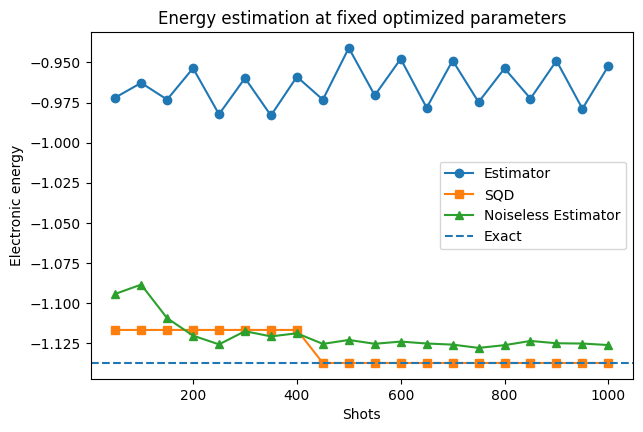

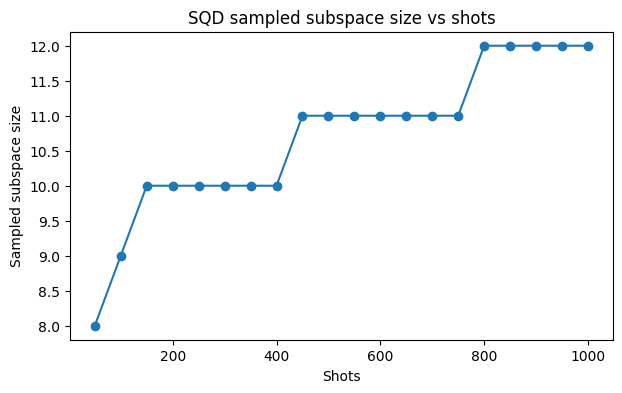

shots= 50 | Estimator=-0.9718979916 | SQD=-1.1166843800 | Noiseless=-1.0942301256 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=4.304e-02 | dim=8
shots=100 | Estimator=-0.9627161090 | SQD=-1.1166843800 | Noiseless=-1.0884416624 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=4.883e-02 | dim=9
shots=150 | Estimator=-0.9731201368 | SQD=-1.1166843800 | Noiseless=-1.1093375256 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=2.793e-02 | dim=10
shots=200 | Estimator=-0.9535857759 | SQD=-1.1166843800 | Noiseless=-1.1202386792 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.703e-02 | dim=10
shots=250 | Estimator=-0.9822842209 | SQD=-1.1166843800 | Noiseless=-1.1256916386 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.158e-02 | dim=10
shots=300 | Estimator=-0.9597593735 | SQD=-1.1166843800 | Noiseless=-1.1174610820 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.981e-02 | dim=10
shots=350 | Estimator=-0.9830410442 | SQD=-1.1166843800 | Noiseless=-1.1207169166 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.655e

In [20]:
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.primitives import Estimator as AerEstimator


max_shots = 1000
step_shots = 50
shot_grid = list(range(step_shots, max_shots + 1, step_shots))

# `backend` should be a backend object chosen earlier in the notebook.
noise_model = NoiseModel.from_backend(backend)

# Noisy sampler for obtaining raw bitstrings.
noisy_sampler = AerSampler(
    seed=1234,
    options={
        "backend_options": {
            "noise_model": noise_model,
            "method": "density_matrix",
        }
    },
)

# Finite-shot noisy estimator.
noisy_estimator = AerEstimator(
    approximation=False,
    backend_options={
        "noise_model": noise_model,
        "method": "density_matrix",
    },
    run_options={
        "seed": 1234,
    },
)

# Finite-shot noiseless estimator.
noiseless_estimator = AerEstimator(
    approximation=False,
    backend_options={
        "noise_model": None,
        "method": "density_matrix",
    },
    run_options={
        "seed": 1234,
    },
)

# Draw one maximum-shot sample record once, then use its prefixes for SQD.
all_samples = sample_bitstrings(ansatz, ideal_vqe_theta, noisy_sampler, shots=max_shots)

comparison = []

for shots in shot_grid:
    prefix_samples = all_samples[:shots]
    sqd_energy = sqd_energy_from_samples(prefix_samples, H2_matrix)

    est_result = noisy_estimator.run([ansatz], [H2_ham], [ideal_vqe_theta], shots=shots).result()
    estimator_energy = float(np.real(est_result.values[0]))

    noiseless_est_result = noiseless_estimator.run([ansatz], [H2_ham], [ideal_vqe_theta], shots=shots).result()
    noiseless_energy = float(np.real(noiseless_est_result.values[0]))

    comparison.append((shots, estimator_energy, sqd_energy, noiseless_energy, len(set(prefix_samples))))

shots = [x[0] for x in comparison]
estimator_energies = [x[1] for x in comparison]
sqd_energies = [x[2] for x in comparison]
noiseless_energies = [x[3] for x in comparison]
subspace_sizes = [x[4] for x in comparison]

plt.figure(figsize=(7, 4.5))
plt.plot(shots, estimator_energies, marker="o", label="Estimator")
plt.plot(shots, sqd_energies, marker="s", label="SQD")
plt.plot(shots, noiseless_energies, marker="^", label="Noiseless Estimator")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Shots")
plt.ylabel("Electronic energy")
plt.title("Energy estimation at fixed optimized parameters")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4.0))
plt.plot(shots, subspace_sizes, marker="o")
plt.xlabel("Shots")
plt.ylabel("Sampled subspace size")
plt.title("SQD sampled subspace size vs shots")
plt.show()

for shots_i, e_est, e_sqd, e_noiseless, dim in comparison:
    print(
        f"shots={shots_i:3d} | "
        f"Estimator={e_est:.10f} | "
        f"SQD={e_sqd:.10f} | "
        f"Noiseless={e_noiseless:.10f} | "
        f"|SQD-Exact|={abs(e_sqd - exact_gnd):.3e} | "
        f"|Noiseless-Exact|={abs(e_noiseless - exact_gnd):.3e} | "
        f"dim={dim}"
    )


------

## Conclusion

In this tutorial, we used the `H2` Hamiltonian as a minimal but complete example of quantum ground-state estimation. We started from the explicit qubit Hamiltonian, obtained the exact classical reference by diagonalization, and then followed the VQE workflow from ansatz construction to primitive-based execution and optimization.
We also compared two different estimation strategies: direct expectation estimation with the Estimator primitive, and an SQD-style sampled-subspace reconstruction.

------